In [30]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, recall_score

In [31]:
# Download the preprocessed data
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv").squeeze()
y_test = pd.read_csv("../clean_data/y_test.csv").squeeze()


In [32]:
# Encodage de la variaable mois en variables sin et cos pour capturer la cyclicité
X_train["Month_sin"] = np.sin(2 * np.pi * X_train["Month"] / 12)
X_train["Month_cos"] = np.cos(2 * np.pi * X_train["Month"] / 12)

X_test["Month_sin"] = np.sin(2 * np.pi * X_test["Month"] / 12)
X_test["Month_cos"] = np.cos(2 * np.pi * X_test["Month"] / 12)

# Encodage de la variable "Day" en variables sin et cos pour capturer la cyclicité
X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day"] / 31)
X_train["Day_cos"] = np.cos(2 * np.pi * X_train["Day"] / 31)

X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day"] / 31)
X_test["Day_cos"] = np.cos(2 * np.pi * X_test["Day"] / 31)

# Sppression de la variable "Month" et "Day" après l'encodage
X_train = X_train.drop(columns=["Month", "Day"])
X_test = X_test.drop(columns=["Month", "Day"])

In [33]:
# 1. Préparation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# 2. Définition du modèle
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Sortie pour classification binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# 3. Entraînement
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, validation_split=0.2,
                    epochs=50, batch_size=64, callbacks=[early_stopping])

# 4. Évaluation
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
conf_matrix = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nRecall: {recall:.4f}")

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9472 - loss: 0.2414 - val_accuracy: 0.9553 - val_loss: 0.1863
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.2192 - val_accuracy: 0.9553 - val_loss: 0.1821
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.2128 - val_accuracy: 0.9553 - val_loss: 0.1814
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.2067 - val_accuracy: 0.9553 - val_loss: 0.1820
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.2044 - val_accuracy: 0.9553 - val_loss: 0.1812
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.2014 - val_accuracy: 0.9553 - val_loss: 0.1815
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.1991 - val_accuracy: 0.9553 - val_loss: 0.1820
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9506 - loss: 0.1965 - val_accuracy: 0.

C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

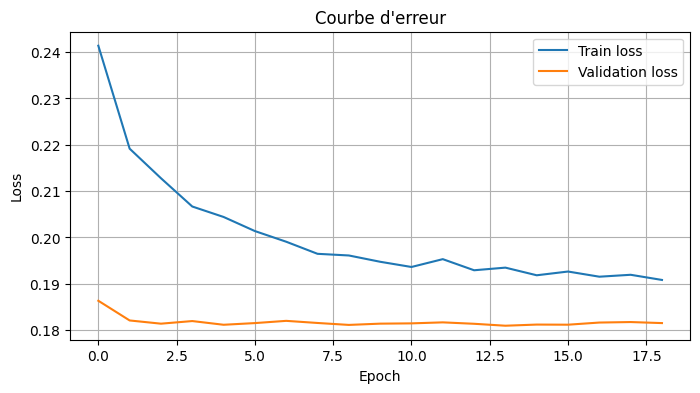

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Courbe d'erreur")
plt.legend()
plt.grid(True)
plt.show()